In [ ]:
# FraudGuard — Model Improvement

## Day 4

### Objective

Improve upon the Day 3 Logistic Regression baseline using stronger nonlinear modeling techniques while preserving the leakage-safe validation strategy.

### Baseline

- Model: Logistic Regression
- Features: 891
- ROC-AUC: 0.8054
- PR-AUC: 0.1622
- Best tested F1: 0.2843 at threshold 0.80

### Today's Goals

- Establish a stronger tree-based baseline.
- Compare performance against Logistic Regression.
- Analyze feature importance.
- Evaluate ROC-AUC and PR-AUC.
- Optimize the fraud detection threshold.
- Keep the validation methodology unchanged.

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

print("Project root:", PROJECT_ROOT)
print("\nProject files:")

for path in sorted(PROJECT_ROOT.rglob("*")):
    if path.is_file():
        print(path.relative_to(PROJECT_ROOT))

Project root: /Users/ayushkumar/Desktop/Fraudguard

Project files:
.git/.COMMIT_EDITMSG.swp
.git/COMMIT_EDITMSG
.git/FETCH_HEAD
.git/HEAD
.git/config
.git/description
.git/hooks/applypatch-msg.sample
.git/hooks/commit-msg.sample
.git/hooks/fsmonitor-watchman.sample
.git/hooks/post-update.sample
.git/hooks/pre-applypatch.sample
.git/hooks/pre-commit.sample
.git/hooks/pre-merge-commit.sample
.git/hooks/pre-push.sample
.git/hooks/pre-rebase.sample
.git/hooks/pre-receive.sample
.git/hooks/prepare-commit-msg.sample
.git/hooks/push-to-checkout.sample
.git/hooks/sendemail-validate.sample
.git/hooks/update.sample
.git/index
.git/info/exclude
.git/logs/HEAD
.git/logs/refs/heads/main
.git/logs/refs/remotes/origin/HEAD
.git/logs/refs/remotes/origin/main
.git/objects/0b/44c1261aab9aefe1d9c38631968b0d20845274
.git/objects/20/15ad672384d8a19ce95dbbc70a62ceb8ec3497
.git/objects/2c/eef12fb7f90d147c4125002b6ecb39054c74f7
.git/objects/33/66e04b4a4c4583658c1f7b2bf6014721bbaf3a
.git/objects/5e/87279ec6ff0

In [2]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack

pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"

TRAIN_TRANSACTION = DATA_RAW / "train_transaction.csv"
TRAIN_IDENTITY = DATA_RAW / "train_identity.csv"

In [3]:
train_transaction = pd.read_csv(TRAIN_TRANSACTION)
train_identity = pd.read_csv(TRAIN_IDENTITY)

train = train_transaction.merge(
    train_identity,
    on="TransactionID",
    how="left"
)

print("Merged shape:", train.shape)

Merged shape: (590540, 434)


In [4]:
SECONDS_PER_HOUR = 60 * 60
SECONDS_PER_DAY = 24 * SECONDS_PER_HOUR

train["transaction_hour"] = (
    (train["TransactionDT"] // SECONDS_PER_HOUR) % 24
)

train["transaction_day"] = (
    train["TransactionDT"] // SECONDS_PER_DAY
)

train["transaction_week"] = (
    train["transaction_day"] // 7
)

train["hour_sin"] = np.sin(
    2 * np.pi * train["transaction_hour"] / 24
)

train["hour_cos"] = np.cos(
    2 * np.pi * train["transaction_hour"] / 24
)

train["identity_present"] = (
    train["id_01"].notna().astype(int)
)

In [5]:
missingness_features = [
    col for col in train.columns
    if col not in ["TransactionID", "isFraud"]
]

train["missing_feature_count"] = (
    train[missingness_features].isna().sum(axis=1)
)

selected_missing_features = [
    "addr1",
    "addr2",
    "M1",
    "M2",
    "M3",
    "M6"
]

for feature in selected_missing_features:
    train[f"{feature}_missing"] = (
        train[feature].isna().astype(int)
    )

In [6]:
TRAIN_END_DAY = 145

train_data = train[
    train["transaction_day"] <= TRAIN_END_DAY
].copy()

validation_data = train[
    train["transaction_day"] > TRAIN_END_DAY
].copy()

TARGET = "isFraud"
ID_COLUMN = "TransactionID"

X_train = train_data.drop(
    columns=[TARGET, ID_COLUMN]
)

y_train = train_data[TARGET]

X_validation = validation_data.drop(
    columns=[TARGET, ID_COLUMN]
)

y_validation = validation_data[TARGET]

print("Training:", X_train.shape)
print("Validation:", X_validation.shape)

Training: (484847, 445)
Validation: (105693, 445)


In [7]:
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))

print("\nCategorical:")
print(categorical_features)

print("\nNumerical:", numerical_features[:20])

Categorical features: 31
Numerical features: 414

Categorical:
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']

Numerical: ['TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1', 'dist2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10']


In [8]:
other_features = [
    col for col in X_train.columns
    if col not in categorical_features + numerical_features
]

print("\nOther feature types:", other_features)


Other feature types: []


In [9]:
X_train_final
X_validation_final
y_train
y_validation

NameError: name 'X_train_final' is not defined

In [10]:
processed_dir = PROJECT_ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

print("Processed directory:", processed_dir)

Processed directory: /Users/ayushkumar/Desktop/Fraudguard/data/processed


In [11]:
numerical_imputer = SimpleImputer(
    strategy="median"
)

X_train_num = numerical_imputer.fit_transform(
    X_train[numerical_features]
)

X_validation_num = numerical_imputer.transform(
    X_validation[numerical_features]
)

print("Numerical train:", X_train_num.shape)
print("Numerical validation:", X_validation_num.shape)

Numerical train: (484847, 414)
Numerical validation: (105693, 414)


In [12]:
print(
    "Train missing:",
    np.isnan(X_train_num).sum()
)

print(
    "Validation missing:",
    np.isnan(X_validation_num).sum()
)

Train missing: 0
Validation missing: 0


In [13]:
RARE_THRESHOLD = 50

categorical_maps = {}

for feature in categorical_features:

    values = X_train[feature].fillna("__MISSING__")

    counts = values.value_counts()

    frequent_categories = counts[
        counts >= RARE_THRESHOLD
    ].index

    categorical_maps[feature] = set(
        frequent_categories
    )

print(
    "Categorical mappings created:",
    len(categorical_maps)
)

Categorical mappings created: 31


In [14]:
def transform_categorical(
    df,
    categorical_columns,
    categorical_maps
):
    df = df[categorical_columns].copy()

    for feature in categorical_columns:

        df[feature] = df[feature].fillna(
            "__MISSING__"
        )

        frequent_categories = categorical_maps[
            feature
        ]

        df[feature] = df[feature].where(
            df[feature].isin(frequent_categories),
            "__RARE__"
        )

    return df

In [15]:
X_train_cat = transform_categorical(
    X_train,
    categorical_features,
    categorical_maps
)

X_validation_cat = transform_categorical(
    X_validation,
    categorical_features,
    categorical_maps
)

In [16]:
categorical_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True,
    dtype=np.float32
)

X_train_cat_encoded = categorical_encoder.fit_transform(
    X_train_cat
)

X_validation_cat_encoded = categorical_encoder.transform(
    X_validation_cat
)

print(
    "Categorical encoded train:",
    X_train_cat_encoded.shape
)

print(
    "Categorical encoded validation:",
    X_validation_cat_encoded.shape
)

Categorical encoded train: (484847, 477)
Categorical encoded validation: (105693, 477)


In [17]:
X_train_final = hstack([
    X_train_num,
    X_train_cat_encoded
]).tocsr()

X_validation_final = hstack([
    X_validation_num,
    X_validation_cat_encoded
]).tocsr()

print(
    "Final training:",
    X_train_final.shape
)

print(
    "Final validation:",
    X_validation_final.shape
)

Final training: (484847, 891)
Final validation: (105693, 891)


In [18]:
from scipy.sparse import save_npz

save_npz(
    processed_dir / "X_train.npz",
    X_train_final
)

save_npz(
    processed_dir / "X_validation.npz",
    X_validation_final
)

y_train.to_csv(
    processed_dir / "y_train.csv",
    index=False
)

y_validation.to_csv(
    processed_dir / "y_validation.csv",
    index=False
)

print("Processed datasets saved successfully.")

Processed datasets saved successfully.


In [19]:
for file in sorted(processed_dir.iterdir()):
    print(
        file.name,
        f"{file.stat().st_size / (1024**2):.2f} MB"
    )

X_train.npz 47.20 MB
X_validation.npz 10.53 MB
y_train.csv 0.92 MB
y_validation.csv 0.20 MB


In [20]:
from scipy.sparse import load_npz

X_train_final = load_npz(
    processed_dir / "X_train.npz"
)

X_validation_final = load_npz(
    processed_dir / "X_validation.npz"
)

y_train = pd.read_csv(
    processed_dir / "y_train.csv"
).squeeze()

y_validation = pd.read_csv(
    processed_dir / "y_validation.csv"
).squeeze()

print("Training:", X_train_final.shape)
print("Validation:", X_validation_final.shape)
print("Train target:", y_train.shape)
print("Validation target:", y_validation.shape)

Training: (484847, 891)
Validation: (105693, 891)
Train target: (484847,)
Validation target: (105693,)


In [21]:
try:
    import lightgbm as lgb
    print("LightGBM version:", lgb.__version__)
except ImportError:
    print("LightGBM is not installed.")

LightGBM is not installed.


In [22]:
models_available = {}

try:
    import xgboost as xgb
    models_available["XGBoost"] = xgb.__version__
except ImportError:
    models_available["XGBoost"] = "Not installed"

try:
    import catboost
    models_available["CatBoost"] = catboost.__version__
except ImportError:
    models_available["CatBoost"] = "Not installed"

print(models_available)

{'XGBoost': 'Not installed', 'CatBoost': 'Not installed'}


In [23]:
import sys

print("Python:", sys.version)
print("Executable:", sys.executable)

Python: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 11:23:37) [Clang 14.0.6 ]
Executable: /opt/homebrew/anaconda3/bin/python


In [1]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)
print("Python executable:", __import__("sys").executable)

XGBoost version: 3.4.1
Python executable: /opt/homebrew/anaconda3/bin/python


In [2]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_final,
    y_train,
    eval_set=[
        (X_validation_final, y_validation)
    ],
    verbose=50
)

print("XGBoost model trained successfully.")

NameError: name 'X_train_final' is not defined

In [3]:
from pathlib import Path
import pandas as pd

from scipy.sparse import load_npz

PROJECT_ROOT = Path.cwd().parent
processed_dir = PROJECT_ROOT / "data" / "processed"

X_train_final = load_npz(
    processed_dir / "X_train.npz"
)

X_validation_final = load_npz(
    processed_dir / "X_validation.npz"
)

y_train = pd.read_csv(
    processed_dir / "y_train.csv"
).squeeze()

y_validation = pd.read_csv(
    processed_dir / "y_validation.csv"
).squeeze()

print("X_train:", X_train_final.shape)
print("X_validation:", X_validation_final.shape)
print("y_train:", y_train.shape)
print("y_validation:", y_validation.shape)

X_train: (484847, 891)
X_validation: (105693, 891)
y_train: (484847,)
y_validation: (105693,)


In [4]:
print("Training matrix:", type(X_train_final))
print("Validation matrix:", type(X_validation_final))

Training matrix: <class 'scipy.sparse._csr.csr_matrix'>
Validation matrix: <class 'scipy.sparse._csr.csr_matrix'>


In [5]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_final,
    y_train,
    eval_set=[
        (X_validation_final, y_validation)
    ],
    verbose=50
)

print("XGBoost model trained successfully.")

[0]	validation_0-aucpr:0.34716
[50]	validation_0-aucpr:0.47365
[100]	validation_0-aucpr:0.50242
[150]	validation_0-aucpr:0.51719
[200]	validation_0-aucpr:0.52459
[250]	validation_0-aucpr:0.53300
[299]	validation_0-aucpr:0.53910
XGBoost model trained successfully.


In [6]:
y_validation_proba_xgb = xgb_model.predict_proba(
    X_validation_final
)[:, 1]

print(y_validation_proba_xgb[:10])

[0.00957129 0.02381421 0.07689995 0.00498742 0.03411664 0.01995293
 0.00663578 0.00428826 0.01308464 0.02979721]


In [7]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

xgb_roc_auc = roc_auc_score(
    y_validation,
    y_validation_proba_xgb
)

xgb_pr_auc = average_precision_score(
    y_validation,
    y_validation_proba_xgb
)

print(f"XGBoost ROC-AUC: {xgb_roc_auc:.4f}")
print(f"XGBoost PR-AUC:  {xgb_pr_auc:.4f}")

XGBoost ROC-AUC: 0.9049
XGBoost PR-AUC:  0.5391


In [8]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

thresholds = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]

xgb_threshold_results = []

for threshold in thresholds:

    y_pred = (
        y_validation_proba_xgb >= threshold
    ).astype(int)

    xgb_threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_validation,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_validation,
            y_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_validation,
            y_pred,
            zero_division=0
        )
    })

xgb_threshold_results = pd.DataFrame(
    xgb_threshold_results
)

display(xgb_threshold_results)

,threshold,precision,recall,f1
0,0.1,0.346491,0.634450,0.448205
1,0.2,0.516364,0.511216,0.513777
2,0.3,0.628235,0.443644,0.520045
3,0.4,0.716559,0.399058,0.512629
4,0.5,0.779049,0.358349,0.490895
5,0.6,0.819157,0.317364,0.457485
6,0.7,0.853721,0.276378,0.417573
7,0.8,0.897704,0.238161,0.376450
8,0.9,0.925484,0.171975,0.290051


In [9]:
from sklearn.metrics import confusion_matrix

threshold = 0.3

y_pred_xgb = (
    y_validation_proba_xgb >= threshold
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_validation,
    y_pred_xgb
).ravel()

print("Threshold:", threshold)
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

print("\nTotal flagged:", fp + tp)
print("Fraud caught:", tp)
print("Fraud missed:", fn)

Threshold: 0.3
True Negatives : 101134
False Positives: 948
False Negatives: 2009
True Positives  : 1602

Total flagged: 2550
Fraud caught: 1602
Fraud missed: 2009


In [10]:
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

display(
    feature_importance.head(30)
)

NameError: name 'feature_names' is not defined

In [11]:
feature_names = np.concatenate([
    numerical_features,
    categorical_encoder.get_feature_names_out(
        categorical_features
    )
])

print("Total feature names:", len(feature_names))

NameError: name 'np' is not defined

In [12]:
import numpy as np
import pandas as pd

print("NumPy:", np.__version__)

NumPy: 2.1.3


In [13]:
feature_names = np.concatenate([
    numerical_features,
    categorical_encoder.get_feature_names_out(
        categorical_features
    )
])

print("Total feature names:", len(feature_names))

NameError: name 'numerical_features' is not defined

In [14]:
print(type(xgb_model))


<class 'xgboost.sklearn.XGBClassifier'>


In [15]:
# Save the exact feature names used by the final ML matrix

feature_names = np.concatenate([
    numerical_features,
    categorical_encoder.get_feature_names_out(
        categorical_features
    )
])

print("Total feature names:", len(feature_names))

pd.DataFrame({
    "feature": feature_names
}).to_csv(
    processed_dir / "feature_names.csv",
    index=False
)

print("Feature names saved successfully.")

NameError: name 'numerical_features' is not defined

In [16]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import OneHotEncoder

# --------------------------------------------------
# 1. Paths
# --------------------------------------------------

PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
processed_dir = PROJECT_ROOT / "data" / "processed"

# --------------------------------------------------
# 2. Load raw data
# --------------------------------------------------

train_transaction = pd.read_csv(
    DATA_RAW / "train_transaction.csv"
)

train_identity = pd.read_csv(
    DATA_RAW / "train_identity.csv"
)

train = train_transaction.merge(
    train_identity,
    on="TransactionID",
    how="left"
)

# --------------------------------------------------
# 3. Recreate EXACT Day 3 engineered features
# --------------------------------------------------

SECONDS_PER_HOUR = 60 * 60
SECONDS_PER_DAY = 24 * SECONDS_PER_HOUR

train["transaction_hour"] = (
    (train["TransactionDT"] // SECONDS_PER_HOUR) % 24
)

train["transaction_day"] = (
    train["TransactionDT"] // SECONDS_PER_DAY
)

train["transaction_week"] = (
    train["transaction_day"] // 7
)

train["hour_sin"] = np.sin(
    2 * np.pi * train["transaction_hour"] / 24
)

train["hour_cos"] = np.cos(
    2 * np.pi * train["transaction_hour"] / 24
)

train["identity_present"] = (
    train["id_01"].notna().astype(int)
)

missingness_features = [
    col for col in train.columns
    if col not in ["TransactionID", "isFraud"]
]

train["missing_feature_count"] = (
    train[missingness_features].isna().sum(axis=1)
)

selected_missing_features = [
    "addr1",
    "addr2",
    "M1",
    "M2",
    "M3",
    "M6"
]

for feature in selected_missing_features:
    train[f"{feature}_missing"] = (
        train[feature].isna().astype(int)
    )

# --------------------------------------------------
# 4. Recreate the EXACT Day 3 training split
# --------------------------------------------------

TRAIN_END_DAY = 145

train_data = train[
    train["transaction_day"] <= TRAIN_END_DAY
].copy()

X_train_reference = train_data.drop(
    columns=["isFraud", "TransactionID"]
)

# --------------------------------------------------
# 5. Recover numerical + categorical features
# --------------------------------------------------

numerical_features = X_train_reference.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train_reference.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 414
Categorical features: 31


In [17]:
RARE_THRESHOLD = 50

X_train_cat = X_train_reference[
    categorical_features
].copy()

for feature in categorical_features:

    X_train_cat[feature] = (
        X_train_cat[feature]
        .fillna("__MISSING__")
    )

    counts = X_train_cat[feature].value_counts()

    frequent_categories = counts[
        counts >= RARE_THRESHOLD
    ].index

    X_train_cat[feature] = X_train_cat[feature].where(
        X_train_cat[feature].isin(frequent_categories),
        "__RARE__"
    )

In [18]:
categorical_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True,
    dtype=np.float32
)

categorical_encoder.fit(X_train_cat)

OneHotEncoder(dtype=<class 'numpy.float32'>, handle_unknown='ignore')

In [19]:
feature_names = np.concatenate([
    numerical_features,
    categorical_encoder.get_feature_names_out(
        categorical_features
    )
])

print("Total feature names:", len(feature_names))

Total feature names: 891


In [20]:
pd.DataFrame({
    "feature": feature_names
}).to_csv(
    processed_dir / "feature_names.csv",
    index=False
)

print("Feature names saved successfully.")

Feature names saved successfully.


In [21]:
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

display(feature_importance.head(30))

,feature,importance
296,V258,0.206636
332,V294,0.026769
108,V70,0.020916
16,C7,0.017973
13,C4,0.017440
129,V91,0.014329
128,V90,0.013207
185,V147,0.012291
187,V149,0.011432
23,C14,0.011056


In [22]:
top_features = feature_importance.head(20).sort_values(
    "importance"
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("XGBoost Importance")
plt.ylabel("Feature")
plt.title("Top 20 XGBoost Features")

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [23]:
import matplotlib.pyplot as plt

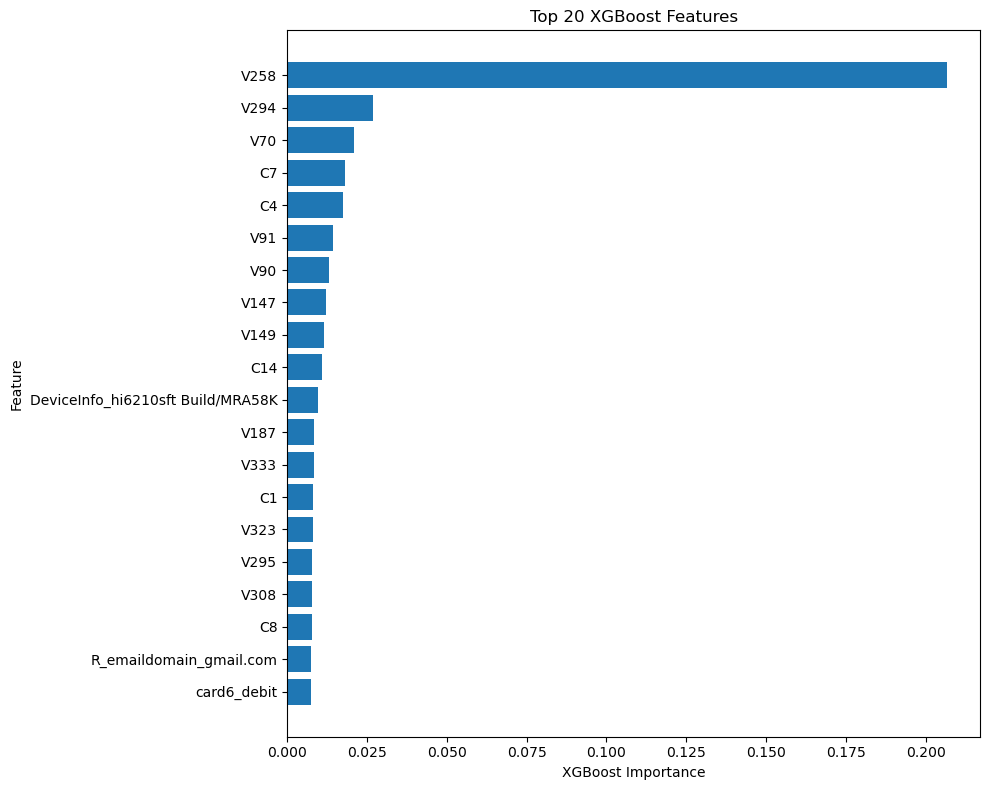

In [24]:
top_features = feature_importance.head(20).sort_values(
    "importance"
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("XGBoost Importance")
plt.ylabel("Feature")
plt.title("Top 20 XGBoost Features")

plt.tight_layout()
plt.show()

In [25]:
print(
    train["V258"].describe()
)

count    130430.000000
mean          1.343510
std           2.015811
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          66.000000
Name: V258, dtype: float64


In [26]:
v258_analysis = train.groupby(
    pd.qcut(
        train["V258"],
        q=10,
        duplicates="drop"
    ),
    observed=False
)["isFraud"].agg(
    count="count",
    fraud_count="sum",
    fraud_rate="mean"
)

v258_analysis["fraud_percentage"] = (
    v258_analysis["fraud_rate"] * 100
)

display(v258_analysis)

,count,fraud_count,fraud_rate,fraud_percentage
V258,,,,
"(-0.001, 1.0]",112959,4485,0.039705,3.970467
"(1.0, 2.0]",11247,1900,0.168934,16.893394
"(2.0, 66.0]",6224,3807,0.611665,61.166452


In [27]:
print(train["V294"].describe())

count    590528.000000
mean          2.313863
std          39.526468
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        1286.000000
Name: V294, dtype: float64


In [28]:
v294_analysis = train.groupby(
    pd.qcut(
        train["V294"],
        q=10,
        duplicates="drop"
    ),
    observed=False
)["isFraud"].agg(
    count="count",
    fraud_count="sum",
    fraud_rate="mean"
)

v294_analysis["fraud_percentage"] = (
    v294_analysis["fraud_rate"] * 100
)

display(v294_analysis)

,count,fraud_count,fraud_rate,fraud_percentage
V294,,,,
"(-0.001, 1.0]",548995,16657,0.030341,3.034090
"(1.0, 1286.0]",41533,4004,0.096405,9.640527


In [29]:
print(train["V70"].describe())

count    513444.000000
mean          0.407924
std           0.554499
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           6.000000
Name: V70, dtype: float64


In [30]:
v70_analysis = train.groupby(
    pd.qcut(
        train["V70"],
        q=10,
        duplicates="drop"
    ),
    observed=False
)["isFraud"].agg(
    count="count",
    fraud_count="sum",
    fraud_rate="mean"
)

v70_analysis["fraud_percentage"] = (
    v70_analysis["fraud_rate"] * 100
)

display(v70_analysis)

,count,fraud_count,fraud_rate,fraud_percentage
V70,,,,
"(-0.001, 1.0]",501978,15988,0.031850,3.185000
"(1.0, 6.0]",11466,166,0.014478,1.447759


In [31]:
validation_analysis = pd.DataFrame({
    "transaction_day": train.loc[
        validation_data.index,
        "transaction_day"
    ].values,
    "isFraud": y_validation.values,
    "prediction": y_validation_proba_xgb
})

validation_analysis["time_period"] = pd.cut(
    validation_analysis["transaction_day"],
    bins=[145, 157, 169, 182],
    labels=["Early", "Middle", "Late"],
    include_lowest=True
)

display(
    validation_analysis.groupby(
        "time_period",
        observed=False
    ).agg(
        transactions=("isFraud", "count"),
        fraud_count=("isFraud", "sum"),
        fraud_rate=("isFraud", "mean")
    )
)

NameError: name 'validation_data' is not defined

In [32]:
TRAIN_END_DAY = 145

validation_mask = (
    train["transaction_day"] > TRAIN_END_DAY
)

validation_days = train.loc[
    validation_mask,
    "transaction_day"
].values

print("Validation transactions:", len(validation_days))
print("First validation day:", validation_days.min())
print("Last validation day:", validation_days.max())

Validation transactions: 105693
First validation day: 146
Last validation day: 182


In [33]:
validation_analysis = pd.DataFrame({
    "transaction_day": validation_days,
    "isFraud": y_validation.values,
    "prediction": y_validation_proba_xgb
})

validation_analysis["time_period"] = pd.cut(
    validation_analysis["transaction_day"],
    bins=[145, 157, 169, 182],
    labels=["Early", "Middle", "Late"],
    include_lowest=True
)

display(
    validation_analysis.groupby(
        "time_period",
        observed=False
    ).agg(
        transactions=("isFraud", "count"),
        fraud_count=("isFraud", "sum"),
        fraud_rate=("isFraud", "mean")
    )
)

,transactions,fraud_count,fraud_rate
time_period,,,
Early,35337,1079,0.030535
Middle,35854,1198,0.033413
Late,34502,1334,0.038664


In [34]:
from sklearn.metrics import average_precision_score

period_results = []

for period, group in validation_analysis.groupby(
    "time_period",
    observed=False
):
    pr_auc = average_precision_score(
        group["isFraud"],
        group["prediction"]
    )

    period_results.append({
        "time_period": period,
        "transactions": len(group),
        "fraud_count": group["isFraud"].sum(),
        "PR-AUC": pr_auc
    })

period_results = pd.DataFrame(period_results)

display(period_results)

,time_period,transactions,fraud_count,PR-AUC
0,Early,35337,1079,0.542293
1,Middle,35854,1198,0.516807
2,Late,34502,1334,0.557187


In [35]:
# ==========================================
# Day 4 — Final Model Results
# ==========================================

day4_results = {
    "baseline_model": "Logistic Regression",
    "baseline_roc_auc": 0.8054,
    "baseline_pr_auc": 0.1622,

    "final_model": "XGBoost",
    "xgb_roc_auc": 0.9049,
    "xgb_pr_auc": 0.5391,

    "best_tested_threshold": 0.30,
    "precision_at_threshold": 0.6282,
    "recall_at_threshold": 0.4436,
    "f1_at_threshold": 0.5200,

    "true_negatives": 101134,
    "false_positives": 948,
    "false_negatives": 2009,
    "true_positives": 1602,

    "fraud_caught": 1602,
    "fraud_missed": 2009,
    "total_flagged": 2550
}

for key, value in day4_results.items():
    print(f"{key}: {value}")

baseline_model: Logistic Regression
baseline_roc_auc: 0.8054
baseline_pr_auc: 0.1622
final_model: XGBoost
xgb_roc_auc: 0.9049
xgb_pr_auc: 0.5391
best_tested_threshold: 0.3
precision_at_threshold: 0.6282
recall_at_threshold: 0.4436
f1_at_threshold: 0.52
true_negatives: 101134
false_positives: 948
false_negatives: 2009
true_positives: 1602
fraud_caught: 1602
fraud_missed: 2009
total_flagged: 2550


In [36]:
import joblib

model_path = processed_dir / "xgboost_fraudguard.pkl"

joblib.dump(
    xgb_model,
    model_path
)

print("XGBoost model saved:", model_path)

XGBoost model saved: /Users/ayushkumar/Desktop/Fraudguard/data/processed/xgboost_fraudguard.pkl


In [37]:
feature_importance.to_csv(
    processed_dir / "xgboost_feature_importance.csv",
    index=False
)

print("Feature importance saved.")

Feature importance saved.


In [1]:
print("X_train_final shape:", X_train_final.shape)
print("X_validation_final shape:", X_validation_final.shape)

print("Training target:", y_train.shape)
print("Validation target:", y_validation.shape)

NameError: name 'X_train_final' is not defined

In [3]:
from pathlib import Path

PROJECT_ROOT = Path(
    "/Users/ayushkumar/Desktop/Fraudguard"
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print("Processed directory:", PROCESSED_DIR)
print("Exists:", PROCESSED_DIR.exists())

Processed directory: /Users/ayushkumar/Desktop/Fraudguard/data/processed
Exists: True


In [4]:
import numpy as np
import pandas as pd
from scipy.sparse import load_npz

X_train_final = load_npz(
    PROCESSED_DIR / "X_train.npz"
)

X_validation_final = load_npz(
    PROCESSED_DIR / "X_validation.npz"
)

y_train = pd.read_csv(
    PROCESSED_DIR / "y_train.csv"
)["isFraud"]

y_validation = pd.read_csv(
    PROCESSED_DIR / "y_validation.csv"
)["isFraud"]

print("Training:", X_train_final.shape)
print("Validation:", X_validation_final.shape)
print("y_train:", y_train.shape)
print("y_validation:", y_validation.shape)

Training: (484847, 891)
Validation: (105693, 891)
y_train: (484847,)
y_validation: (105693,)


In [5]:
from xgboost import XGBClassifier

xgb_baseline = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_baseline.fit(
    X_train_final,
    y_train,
    eval_set=[
        (X_validation_final, y_validation)
    ],
    verbose=50
)

print("Baseline XGBoost trained successfully.")

[0]	validation_0-aucpr:0.34716
[50]	validation_0-aucpr:0.47365
[100]	validation_0-aucpr:0.50242
[150]	validation_0-aucpr:0.51719
[200]	validation_0-aucpr:0.52459
[250]	validation_0-aucpr:0.53300
[299]	validation_0-aucpr:0.53910
Baseline XGBoost trained successfully.


In [6]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_validation_proba_baseline = (
    xgb_baseline.predict_proba(
        X_validation_final
    )[:, 1]
)

baseline_roc = roc_auc_score(
    y_validation,
    y_validation_proba_baseline
)

baseline_pr = average_precision_score(
    y_validation,
    y_validation_proba_baseline
)

print(f"Baseline ROC-AUC: {baseline_roc:.4f}")
print(f"Baseline PR-AUC:  {baseline_pr:.4f}")

Baseline ROC-AUC: 0.9049
Baseline PR-AUC:  0.5391


In [7]:
xgb_exp1 = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_exp1.fit(
    X_train_final,
    y_train,
    eval_set=[
        (X_validation_final, y_validation)
    ],
    verbose=50
)

print("Experiment 1 trained successfully.")

[0]	validation_0-aucpr:0.34716
[50]	validation_0-aucpr:0.47365
[100]	validation_0-aucpr:0.50242
[150]	validation_0-aucpr:0.51719
[200]	validation_0-aucpr:0.52459
[250]	validation_0-aucpr:0.53300
[300]	validation_0-aucpr:0.53937
[350]	validation_0-aucpr:0.54234
[400]	validation_0-aucpr:0.54767
[450]	validation_0-aucpr:0.55154
[499]	validation_0-aucpr:0.55475
Experiment 1 trained successfully.


In [8]:
y_validation_proba_exp1 = (
    xgb_exp1.predict_proba(
        X_validation_final
    )[:, 1]
)

exp1_roc = roc_auc_score(
    y_validation,
    y_validation_proba_exp1
)

exp1_pr = average_precision_score(
    y_validation,
    y_validation_proba_exp1
)

print(f"Experiment 1 ROC-AUC: {exp1_roc:.4f}")
print(f"Experiment 1 PR-AUC:  {exp1_pr:.4f}")

Experiment 1 ROC-AUC: 0.9118
Experiment 1 PR-AUC:  0.5548


In [9]:
xgb_exp2 = XGBClassifier(
    n_estimators=700,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_exp2.fit(
    X_train_final,
    y_train,
    eval_set=[
        (X_validation_final, y_validation)
    ],
    verbose=50
)

print("Experiment 2 trained successfully.")

[0]	validation_0-aucpr:0.34716
[50]	validation_0-aucpr:0.47365
[100]	validation_0-aucpr:0.50242
[150]	validation_0-aucpr:0.51719
[200]	validation_0-aucpr:0.52459
[250]	validation_0-aucpr:0.53300
[300]	validation_0-aucpr:0.53937
[350]	validation_0-aucpr:0.54234
[400]	validation_0-aucpr:0.54767
[450]	validation_0-aucpr:0.55154
[500]	validation_0-aucpr:0.55453
[550]	validation_0-aucpr:0.55857
[600]	validation_0-aucpr:0.56222
[650]	validation_0-aucpr:0.56542
[699]	validation_0-aucpr:0.56745
Experiment 2 trained successfully.


In [10]:
y_validation_proba_exp2 = (
    xgb_exp2.predict_proba(
        X_validation_final
    )[:, 1]
)

exp2_roc = roc_auc_score(
    y_validation,
    y_validation_proba_exp2
)

exp2_pr = average_precision_score(
    y_validation,
    y_validation_proba_exp2
)

print(f"Experiment 2 ROC-AUC: {exp2_roc:.4f}")
print(f"Experiment 2 PR-AUC:  {exp2_pr:.4f}")

Experiment 2 ROC-AUC: 0.9155
Experiment 2 PR-AUC:  0.5675


In [11]:
xgb_exp3 = XGBClassifier(
    n_estimators=900,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_exp3.fit(
    X_train_final,
    y_train,
    eval_set=[
        (X_validation_final, y_validation)
    ],
    verbose=100
)

print("Experiment 3 trained successfully.")

[0]	validation_0-aucpr:0.34716
[100]	validation_0-aucpr:0.50242
[200]	validation_0-aucpr:0.52459
[300]	validation_0-aucpr:0.53937
[400]	validation_0-aucpr:0.54767
[500]	validation_0-aucpr:0.55453
[600]	validation_0-aucpr:0.56222
[700]	validation_0-aucpr:0.56723
[800]	validation_0-aucpr:0.57042
[899]	validation_0-aucpr:0.57386
Experiment 3 trained successfully.


In [12]:
y_validation_proba_exp3 = (
    xgb_exp3.predict_proba(
        X_validation_final
    )[:, 1]
)

exp3_roc = roc_auc_score(
    y_validation,
    y_validation_proba_exp3
)

exp3_pr = average_precision_score(
    y_validation,
    y_validation_proba_exp3
)

print(f"Experiment 3 ROC-AUC: {exp3_roc:.4f}")
print(f"Experiment 3 PR-AUC:  {exp3_pr:.4f}")

Experiment 3 ROC-AUC: 0.9174
Experiment 3 PR-AUC:  0.5739


In [13]:
xgb_exp4 = XGBClassifier(
    n_estimators=1100,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_exp4.fit(
    X_train_final,
    y_train,
    eval_set=[
        (X_validation_final, y_validation)
    ],
    verbose=100
)

print("Experiment 4 trained successfully.")

[0]	validation_0-aucpr:0.34716
[100]	validation_0-aucpr:0.50242
[200]	validation_0-aucpr:0.52459
[300]	validation_0-aucpr:0.53937
[400]	validation_0-aucpr:0.54767
[500]	validation_0-aucpr:0.55453
[600]	validation_0-aucpr:0.56222
[700]	validation_0-aucpr:0.56723
[800]	validation_0-aucpr:0.57042
[900]	validation_0-aucpr:0.57391
[1000]	validation_0-aucpr:0.57823
[1099]	validation_0-aucpr:0.58161
Experiment 4 trained successfully.


In [14]:
y_validation_proba_exp4 = (
    xgb_exp4.predict_proba(
        X_validation_final
    )[:, 1]
)

exp4_roc = roc_auc_score(
    y_validation,
    y_validation_proba_exp4
)

exp4_pr = average_precision_score(
    y_validation,
    y_validation_proba_exp4
)

print(f"Experiment 4 ROC-AUC: {exp4_roc:.4f}")
print(f"Experiment 4 PR-AUC:  {exp4_pr:.4f}")

Experiment 4 ROC-AUC: 0.9185
Experiment 4 PR-AUC:  0.5817


In [15]:
xgb_exp5 = XGBClassifier(
    n_estimators=1300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_exp5.fit(
    X_train_final,
    y_train,
    eval_set=[
        (X_validation_final, y_validation)
    ],
    verbose=100
)

print("Experiment 5 trained successfully.")

[0]	validation_0-aucpr:0.34716
[100]	validation_0-aucpr:0.50242
[200]	validation_0-aucpr:0.52459
[300]	validation_0-aucpr:0.53937
[400]	validation_0-aucpr:0.54767
[500]	validation_0-aucpr:0.55453
[600]	validation_0-aucpr:0.56222
[700]	validation_0-aucpr:0.56723
[800]	validation_0-aucpr:0.57042
[900]	validation_0-aucpr:0.57391
[1000]	validation_0-aucpr:0.57823
[1100]	validation_0-aucpr:0.58189
[1200]	validation_0-aucpr:0.58501
[1299]	validation_0-aucpr:0.58789
Experiment 5 trained successfully.


In [16]:
y_validation_proba_exp5 = (
    xgb_exp5.predict_proba(
        X_validation_final
    )[:, 1]
)

exp5_roc = roc_auc_score(
    y_validation,
    y_validation_proba_exp5
)

exp5_pr = average_precision_score(
    y_validation,
    y_validation_proba_exp5
)

print(f"Experiment 5 ROC-AUC: {exp5_roc:.4f}")
print(f"Experiment 5 PR-AUC:  {exp5_pr:.4f}")

Experiment 5 ROC-AUC: 0.9204
Experiment 5 PR-AUC:  0.5879


In [17]:
xgb_exp6 = XGBClassifier(
    n_estimators=1500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_exp6.fit(
    X_train_final,
    y_train,
    eval_set=[
        (X_validation_final, y_validation)
    ],
    verbose=100
)

print("Experiment 6 trained successfully.")

[0]	validation_0-aucpr:0.34716
[100]	validation_0-aucpr:0.50242
[200]	validation_0-aucpr:0.52459
[300]	validation_0-aucpr:0.53937
[400]	validation_0-aucpr:0.54767
[500]	validation_0-aucpr:0.55453
[600]	validation_0-aucpr:0.56222
[700]	validation_0-aucpr:0.56723
[800]	validation_0-aucpr:0.57042
[900]	validation_0-aucpr:0.57391
[1000]	validation_0-aucpr:0.57823
[1100]	validation_0-aucpr:0.58189
[1200]	validation_0-aucpr:0.58501
[1300]	validation_0-aucpr:0.58802
[1400]	validation_0-aucpr:0.58883
[1499]	validation_0-aucpr:0.59152
Experiment 6 trained successfully.


In [18]:
y_validation_proba_exp6 = (
    xgb_exp6.predict_proba(
        X_validation_final
    )[:, 1]
)

exp6_roc = roc_auc_score(
    y_validation,
    y_validation_proba_exp6
)

exp6_pr = average_precision_score(
    y_validation,
    y_validation_proba_exp6
)

print(f"Experiment 6 ROC-AUC: {exp6_roc:.4f}")
print(f"Experiment 6 PR-AUC:  {exp6_pr:.4f}")

Experiment 6 ROC-AUC: 0.9212
Experiment 6 PR-AUC:  0.5916


In [ ]:
### Experiment 6 — 1500 Trees

- n_estimators: 1500
- max_depth: 6
- learning_rate: 0.05
- subsample: 0.8
- colsample_bytree: 0.8
- ROC-AUC: 0.9212
- PR-AUC: 0.5916

Result: Best model so far. Increasing n_estimators from 300 to 1500 produced a substantial improvement in PR-AUC. Further increases will not be tested.

In [19]:
xgb_exp7 = XGBClassifier(
    n_estimators=1500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_exp7.fit(
    X_train_final,
    y_train,
    eval_set=[
        (X_validation_final, y_validation)
    ],
    verbose=100
)

print("Experiment 7 trained successfully.")

[0]	validation_0-aucpr:0.34941
[100]	validation_0-aucpr:0.52774
[200]	validation_0-aucpr:0.54832
[300]	validation_0-aucpr:0.56206
[400]	validation_0-aucpr:0.57194
[500]	validation_0-aucpr:0.57923
[600]	validation_0-aucpr:0.58541
[700]	validation_0-aucpr:0.58830
[800]	validation_0-aucpr:0.59122
[900]	validation_0-aucpr:0.59403
[1000]	validation_0-aucpr:0.59488
[1100]	validation_0-aucpr:0.59635
[1200]	validation_0-aucpr:0.59789
[1300]	validation_0-aucpr:0.59730
[1400]	validation_0-aucpr:0.59853
[1499]	validation_0-aucpr:0.59804
Experiment 7 trained successfully.


In [20]:
y_validation_proba_exp7 = (
    xgb_exp7.predict_proba(
        X_validation_final
    )[:, 1]
)

exp7_roc = roc_auc_score(
    y_validation,
    y_validation_proba_exp7
)

exp7_pr = average_precision_score(
    y_validation,
    y_validation_proba_exp7
)

print(f"Experiment 7 ROC-AUC: {exp7_roc:.4f}")
print(f"Experiment 7 PR-AUC:  {exp7_pr:.4f}")

Experiment 7 ROC-AUC: 0.9227
Experiment 7 PR-AUC:  0.5981


In [21]:
xgb_exp8 = XGBClassifier(
    n_estimators=1500,
    max_depth=8,
    learning_rate=0.07,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_exp8.fit(
    X_train_final,
    y_train,
    eval_set=[
        (X_validation_final, y_validation)
    ],
    verbose=100
)

print("Experiment 8 trained successfully.")

[0]	validation_0-aucpr:0.34941
[100]	validation_0-aucpr:0.53189
[200]	validation_0-aucpr:0.55249
[300]	validation_0-aucpr:0.56620
[400]	validation_0-aucpr:0.57662
[500]	validation_0-aucpr:0.58248
[600]	validation_0-aucpr:0.58694
[700]	validation_0-aucpr:0.58926
[800]	validation_0-aucpr:0.59139
[900]	validation_0-aucpr:0.59271
[1000]	validation_0-aucpr:0.59440
[1100]	validation_0-aucpr:0.59488
[1200]	validation_0-aucpr:0.59710
[1300]	validation_0-aucpr:0.59823
[1400]	validation_0-aucpr:0.59907
[1499]	validation_0-aucpr:0.59924
Experiment 8 trained successfully.


In [22]:
y_validation_proba_exp8 = (
    xgb_exp8.predict_proba(
        X_validation_final
    )[:, 1]
)

exp8_roc = roc_auc_score(
    y_validation,
    y_validation_proba_exp8
)

exp8_pr = average_precision_score(
    y_validation,
    y_validation_proba_exp8
)

print(f"Experiment 8 ROC-AUC: {exp8_roc:.4f}")
print(f"Experiment 8 PR-AUC:  {exp8_pr:.4f}")

Experiment 8 ROC-AUC: 0.9208
Experiment 8 PR-AUC:  0.5993


In [24]:
import joblib

joblib.dump(
    xgb_exp8,
    "xgb_day7_exp8.pkl"
)

np.save(
    "y_validation_proba_exp8.npy",
    y_validation_proba_exp8
)

print("Experiment 8 saved successfully.")

Experiment 8 saved successfully.


In [25]:
day7_results = pd.DataFrame([
    {
        "experiment": "Baseline",
        "n_estimators": 300,
        "max_depth": 6,
        "learning_rate": 0.05,
        "ROC_AUC": 0.9049,
        "PR_AUC": 0.5391
    },
    {
        "experiment": "Exp1",
        "n_estimators": 500,
        "max_depth": 6,
        "learning_rate": 0.05,
        "ROC_AUC": 0.9118,
        "PR_AUC": 0.5548
    },
    {
        "experiment": "Exp2",
        "n_estimators": 700,
        "max_depth": 6,
        "learning_rate": 0.05,
        "ROC_AUC": 0.9155,
        "PR_AUC": 0.5675
    },
    {
        "experiment": "Exp3",
        "n_estimators": 900,
        "max_depth": 6,
        "learning_rate": 0.05,
        "ROC_AUC": 0.9174,
        "PR_AUC": 0.5739
    },
    {
        "experiment": "Exp4",
        "n_estimators": 1100,
        "max_depth": 6,
        "learning_rate": 0.05,
        "ROC_AUC": 0.9185,
        "PR_AUC": 0.5817
    },
    {
        "experiment": "Exp5",
        "n_estimators": 1300,
        "max_depth": 6,
        "learning_rate": 0.05,
        "ROC_AUC": 0.9204,
        "PR_AUC": 0.5879
    },
    {
        "experiment": "Exp6",
        "n_estimators": 1500,
        "max_depth": 6,
        "learning_rate": 0.05,
        "ROC_AUC": 0.9212,
        "PR_AUC": 0.5916
    },
    {
        "experiment": "Exp7",
        "n_estimators": 1500,
        "max_depth": 8,
        "learning_rate": 0.05,
        "ROC_AUC": 0.9227,
        "PR_AUC": 0.5981
    },
    {
        "experiment": "Exp8",
        "n_estimators": 1500,
        "max_depth": 8,
        "learning_rate": 0.07,
        "ROC_AUC": 0.9208,
        "PR_AUC": 0.5993
    }
])

day7_results

,experiment,n_estimators,max_depth,learning_rate,ROC_AUC,PR_AUC
0,Baseline,300,6,0.05,0.9049,0.5391
1,Exp1,500,6,0.05,0.9118,0.5548
2,Exp2,700,6,0.05,0.9155,0.5675
3,Exp3,900,6,0.05,0.9174,0.5739
4,Exp4,1100,6,0.05,0.9185,0.5817
5,Exp5,1300,6,0.05,0.9204,0.5879
6,Exp6,1500,6,0.05,0.9212,0.5916
7,Exp7,1500,8,0.05,0.9227,0.5981
8,Exp8,1500,8,0.07,0.9208,0.5993


In [26]:
day7_results.to_csv(
    "day7_experiment_results.csv",
    index=False
)

print("Day 7 experiment history saved.")

Day 7 experiment history saved.


In [27]:
xgb_exp9 = XGBClassifier(
    n_estimators=1500,
    max_depth=8,
    learning_rate=0.07,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_exp9.fit(
    X_train_final,
    y_train,
    eval_set=[
        (X_validation_final, y_validation)
    ],
    verbose=100
)

print("Experiment 9 trained successfully.")

[0]	validation_0-aucpr:0.37053
[100]	validation_0-aucpr:0.53561
[200]	validation_0-aucpr:0.55309
[300]	validation_0-aucpr:0.56535
[400]	validation_0-aucpr:0.57599
[500]	validation_0-aucpr:0.58178
[600]	validation_0-aucpr:0.58647
[700]	validation_0-aucpr:0.58904
[800]	validation_0-aucpr:0.59130
[900]	validation_0-aucpr:0.59188
[1000]	validation_0-aucpr:0.59380
[1100]	validation_0-aucpr:0.59383
[1200]	validation_0-aucpr:0.59501
[1300]	validation_0-aucpr:0.59483
[1400]	validation_0-aucpr:0.59419
[1499]	validation_0-aucpr:0.59334
Experiment 9 trained successfully.


In [28]:
y_validation_proba_exp9 = (
    xgb_exp9.predict_proba(
        X_validation_final
    )[:, 1]
)

exp9_roc = roc_auc_score(
    y_validation,
    y_validation_proba_exp9
)

exp9_pr = average_precision_score(
    y_validation,
    y_validation_proba_exp9
)

print(f"Experiment 9 ROC-AUC: {exp9_roc:.4f}")
print(f"Experiment 9 PR-AUC:  {exp9_pr:.4f}")

Experiment 9 ROC-AUC: 0.9166
Experiment 9 PR-AUC:  0.5934


In [29]:
xgb_exp10 = XGBClassifier(
    n_estimators=1500,
    max_depth=8,
    learning_rate=0.07,
    min_child_weight=1,
    subsample=0.9,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_exp10.fit(
    X_train_final,
    y_train,
    eval_set=[
        (X_validation_final, y_validation)
    ],
    verbose=100
)

print("Experiment 10 trained successfully.")

[0]	validation_0-aucpr:0.34488
[100]	validation_0-aucpr:0.53186
[200]	validation_0-aucpr:0.55314
[300]	validation_0-aucpr:0.56525
[400]	validation_0-aucpr:0.57419
[500]	validation_0-aucpr:0.57939
[600]	validation_0-aucpr:0.58444
[700]	validation_0-aucpr:0.58694
[800]	validation_0-aucpr:0.58889
[900]	validation_0-aucpr:0.59054
[1000]	validation_0-aucpr:0.59232
[1100]	validation_0-aucpr:0.59401
[1200]	validation_0-aucpr:0.59491
[1300]	validation_0-aucpr:0.59555
[1400]	validation_0-aucpr:0.59471
[1499]	validation_0-aucpr:0.59484
Experiment 10 trained successfully.


In [30]:
xgb_exp11 = XGBClassifier(
    n_estimators=1500,
    max_depth=8,
    learning_rate=0.07,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_exp11.fit(
    X_train_final,
    y_train,
    eval_set=[
        (X_validation_final, y_validation)
    ],
    verbose=100
)

print("Experiment 11 trained successfully.")

[0]	validation_0-aucpr:0.35394
[100]	validation_0-aucpr:0.54016
[200]	validation_0-aucpr:0.56188
[300]	validation_0-aucpr:0.57469
[400]	validation_0-aucpr:0.58387
[500]	validation_0-aucpr:0.59039
[600]	validation_0-aucpr:0.59377
[700]	validation_0-aucpr:0.59657
[800]	validation_0-aucpr:0.59668
[900]	validation_0-aucpr:0.59841
[1000]	validation_0-aucpr:0.59872
[1100]	validation_0-aucpr:0.59884
[1200]	validation_0-aucpr:0.60054
[1300]	validation_0-aucpr:0.60250
[1400]	validation_0-aucpr:0.60334
[1499]	validation_0-aucpr:0.60302
Experiment 11 trained successfully.


In [31]:
y_validation_proba_exp11 = (
    xgb_exp11.predict_proba(
        X_validation_final
    )[:, 1]
)

exp11_roc = roc_auc_score(
    y_validation,
    y_validation_proba_exp11
)

exp11_pr = average_precision_score(
    y_validation,
    y_validation_proba_exp11
)

print(f"Experiment 11 ROC-AUC: {exp11_roc:.4f}")
print(f"Experiment 11 PR-AUC:  {exp11_pr:.4f}")

Experiment 11 ROC-AUC: 0.9219
Experiment 11 PR-AUC:  0.6031


In [32]:
import joblib
import numpy as np

joblib.dump(
    xgb_exp11,
    "xgb_day7_exp11.pkl"
)

np.save(
    "y_validation_proba_exp11.npy",
    y_validation_proba_exp11
)

print("Experiment 11 model and predictions saved successfully.")

Experiment 11 model and predictions saved successfully.


In [33]:
day7_results.loc[len(day7_results)] = {
    "experiment": "Exp11",
    "n_estimators": 1500,
    "max_depth": 8,
    "learning_rate": 0.07,
    "ROC_AUC": 0.9219,
    "PR_AUC": 0.6031
}

day7_results.to_csv(
    "day7_experiment_results.csv",
    index=False
)

display(day7_results)

,experiment,n_estimators,max_depth,learning_rate,ROC_AUC,PR_AUC
0,Baseline,300,6,0.05,0.9049,0.5391
1,Exp1,500,6,0.05,0.9118,0.5548
2,Exp2,700,6,0.05,0.9155,0.5675
3,Exp3,900,6,0.05,0.9174,0.5739
4,Exp4,1100,6,0.05,0.9185,0.5817
5,Exp5,1300,6,0.05,0.9204,0.5879
6,Exp6,1500,6,0.05,0.9212,0.5916
7,Exp7,1500,8,0.05,0.9227,0.5981
8,Exp8,1500,8,0.07,0.9208,0.5993
9,Exp11,1500,8,0.07,0.9219,0.6031


In [34]:
import joblib
import numpy as np

joblib.dump(
    xgb_exp11,
    "xgb_day7_exp11.pkl"
)

np.save(
    "y_validation_proba_exp11.npy",
    y_validation_proba_exp11
)

print("Experiment 11 model saved.")
print("Experiment 11 predictions saved.")

Experiment 11 model saved.
Experiment 11 predictions saved.


In [35]:
import os

print("Model exists:",
      os.path.exists("xgb_day7_exp11.pkl"))

print("Predictions exist:",
      os.path.exists("y_validation_proba_exp11.npy"))

print("Results exists:",
      os.path.exists("day7_experiment_results.csv"))

Model exists: True
Predictions exist: True
Results exists: True


In [36]:
xgb_exp12 = XGBClassifier(
    n_estimators=1500,
    max_depth=8,
    learning_rate=0.07,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.9,
    gamma=0.1,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_exp12.fit(
    X_train_final,
    y_train,
    eval_set=[
        (X_validation_final, y_validation)
    ],
    verbose=100
)

print("Experiment 12 trained successfully.")

[0]	validation_0-aucpr:0.35394
[100]	validation_0-aucpr:0.54016
[200]	validation_0-aucpr:0.56118
[300]	validation_0-aucpr:0.57649
[400]	validation_0-aucpr:0.58457
[500]	validation_0-aucpr:0.58899
[600]	validation_0-aucpr:0.59420
[700]	validation_0-aucpr:0.59725
[800]	validation_0-aucpr:0.59862
[900]	validation_0-aucpr:0.59851
[1000]	validation_0-aucpr:0.59961
[1100]	validation_0-aucpr:0.59962
[1200]	validation_0-aucpr:0.59939
[1300]	validation_0-aucpr:0.59998
[1400]	validation_0-aucpr:0.60161
[1499]	validation_0-aucpr:0.60136
Experiment 12 trained successfully.


In [37]:
y_validation_proba_exp12 = (
    xgb_exp12.predict_proba(
        X_validation_final
    )[:, 1]
)

exp12_roc = roc_auc_score(
    y_validation,
    y_validation_proba_exp12
)

exp12_pr = average_precision_score(
    y_validation,
    y_validation_proba_exp12
)

print(f"Experiment 12 ROC-AUC: {exp12_roc:.4f}")
print(f"Experiment 12 PR-AUC:  {exp12_pr:.4f}")


Experiment 12 ROC-AUC: 0.9213
Experiment 12 PR-AUC:  0.6014


In [38]:
xgb_exp13 = XGBClassifier(
    n_estimators=1500,
    max_depth=8,
    learning_rate=0.07,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.9,
    gamma=0.05,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_exp13.fit(
    X_train_final,
    y_train,
    eval_set=[
        (X_validation_final, y_validation)
    ],
    verbose=100
)

print("Experiment 13 trained successfully.")

[0]	validation_0-aucpr:0.35394
[100]	validation_0-aucpr:0.54117
[200]	validation_0-aucpr:0.55934
[300]	validation_0-aucpr:0.57288
[400]	validation_0-aucpr:0.58122
[500]	validation_0-aucpr:0.58683
[600]	validation_0-aucpr:0.59033
[700]	validation_0-aucpr:0.59182
[800]	validation_0-aucpr:0.59371
[900]	validation_0-aucpr:0.59469
[1000]	validation_0-aucpr:0.59535
[1100]	validation_0-aucpr:0.59816
[1200]	validation_0-aucpr:0.59959
[1300]	validation_0-aucpr:0.59839
[1400]	validation_0-aucpr:0.59845
[1499]	validation_0-aucpr:0.59834
Experiment 13 trained successfully.


In [39]:
y_validation_proba_exp13 = (
    xgb_exp13.predict_proba(
        X_validation_final
    )[:, 1]
)

exp13_roc = roc_auc_score(
    y_validation,
    y_validation_proba_exp13
)

exp13_pr = average_precision_score(
    y_validation,
    y_validation_proba_exp13
)

print(f"Experiment 13 ROC-AUC: {exp13_roc:.4f}")
print(f"Experiment 13 PR-AUC:  {exp13_pr:.4f}")

Experiment 13 ROC-AUC: 0.9217
Experiment 13 PR-AUC:  0.5984


In [40]:
import joblib
import numpy as np

joblib.dump(
    xgb_exp11,
    "xgb_day7_champion.pkl"
)

np.save(
    "y_validation_proba_day7_champion.npy",
    y_validation_proba_exp11
)

print("Day 7 champion saved successfully.")

Day 7 champion saved successfully.


In [41]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

thresholds = [
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50
]

threshold_results = []

for threshold in thresholds:

    y_pred = (
        y_validation_proba_exp11 >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        y_pred
    ).ravel()

    precision = precision_score(
        y_validation,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_validation,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_validation,
        y_pred,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "flagged": fp + tp,
        "true_positive": tp,
        "false_positive": fp,
        "false_negative": fn,
        "true_negative": tn
    })

threshold_results_df = pd.DataFrame(
    threshold_results
)

display(threshold_results_df)

,threshold,precision,recall,f1,flagged,true_positive,false_positive,false_negative,true_negative
0,0.10,0.601315,0.557186,0.578410,3346,2012,1334,1599,100748
1,0.15,0.671609,0.514262,0.582497,2765,1857,908,1754,101174
2,0.20,0.718674,0.492384,0.584388,2474,1778,696,1833,101386
3,0.25,0.752660,0.470230,0.578831,2256,1698,558,1913,101524
4,0.30,0.771090,0.450568,0.568782,2110,1627,483,1984,101599
5,0.35,0.791022,0.439214,0.564815,2005,1586,419,2025,101663
6,0.40,0.810754,0.425921,0.558460,1897,1538,359,2073,101723
7,0.45,0.832031,0.412905,0.551916,1792,1491,301,2120,101781
8,0.50,0.846963,0.401551,0.544806,1712,1450,262,2161,101820


In [42]:
final_threshold = 0.20

y_final_pred = (
    y_validation_proba_exp11 >= final_threshold
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_validation,
    y_final_pred
).ravel()

print("Final Day 7 Model")
print("------------------")
print(f"Threshold       : {final_threshold}")
print(f"True Negatives  : {tn}")
print(f"False Positives : {fp}")
print(f"False Negatives : {fn}")
print(f"True Positives  : {tp}")
print(f"Precision       : {precision_score(y_validation, y_final_pred):.4f}")
print(f"Recall          : {recall_score(y_validation, y_final_pred):.4f}")
print(f"F1              : {f1_score(y_validation, y_final_pred):.4f}")
print(f"Total flagged   : {tp + fp}")


Final Day 7 Model
------------------
Threshold       : 0.2
True Negatives  : 101386
False Positives : 696
False Negatives : 1833
True Positives  : 1778
Precision       : 0.7187
Recall          : 0.4924
F1              : 0.5844
Total flagged   : 2474


In [ ]:
# Day 7 — XGBoost Model Improvement

## Objective

Improve FraudGuard's fraud detection performance through systematic
XGBoost hyperparameter experimentation and select an appropriate
operating threshold.

## Best Model

- Model: XGBoost Classifier
- n_estimators: 1500
- max_depth: 8
- learning_rate: 0.07
- min_child_weight: 1
- subsample: 0.8
- colsample_bytree: 0.9
- gamma: 0

## Validation Performance

- ROC-AUC: 0.9219
- PR-AUC: 0.6031

## Final Operating Threshold

Threshold: 0.20

- Precision: 0.7187
- Recall: 0.4924
- F1-score: 0.5844
- Total flagged: 2,474

## Confusion Matrix

- True Negatives: 101,386
- False Positives: 696
- False Negatives: 1,833
- True Positives: 1,778

## Conclusion

Experiment 11 was selected as the Day 7 champion because it achieved
the highest PR-AUC of 0.6031 among the tested configurations.

A threshold of 0.20 was selected as the default operating threshold
because it produced the highest F1-score (0.5844) in the evaluated
threshold range while maintaining 71.87% precision and 49.24% recall.

The model demonstrates a meaningful improvement in fraud detection
quality compared with the earlier Day 6 model, particularly in
precision and F1-score.